# Object Detection 
## Data Exploration

Before training, we must understand what the data is like by exploring each of the subsets of data (training, validation, and testing).

In [9]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

## Overview
We will check image count of each split.

In [4]:
train_images = os.listdir('../data/train/images')
print(f'Train images count: {len(train_images)}')
val_images = os.listdir('../data/valid/images')
print(f'Validation images count: {len(val_images)}')
test_images = os.listdir('../data/test/images')
print(f'Test images count: {len(test_images)}')
print(f'Total images count: {len(train_images) + len(val_images) + len(test_images)}')

Train images count: 465
Validation images count: 133
Test images count: 67
Total images count: 665


## Sample images
Lets look at example images to see what we are working with.

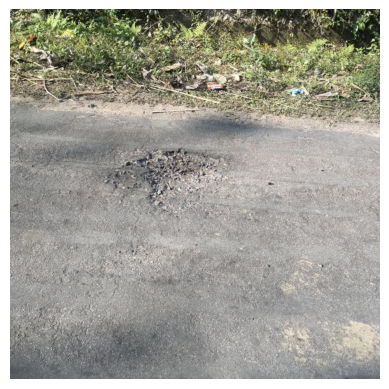

In [7]:
img = mpimg.imread(f'../data/train/images/{train_images[0]}')
plt.imshow(img)
plt.axis('off')
plt.show()

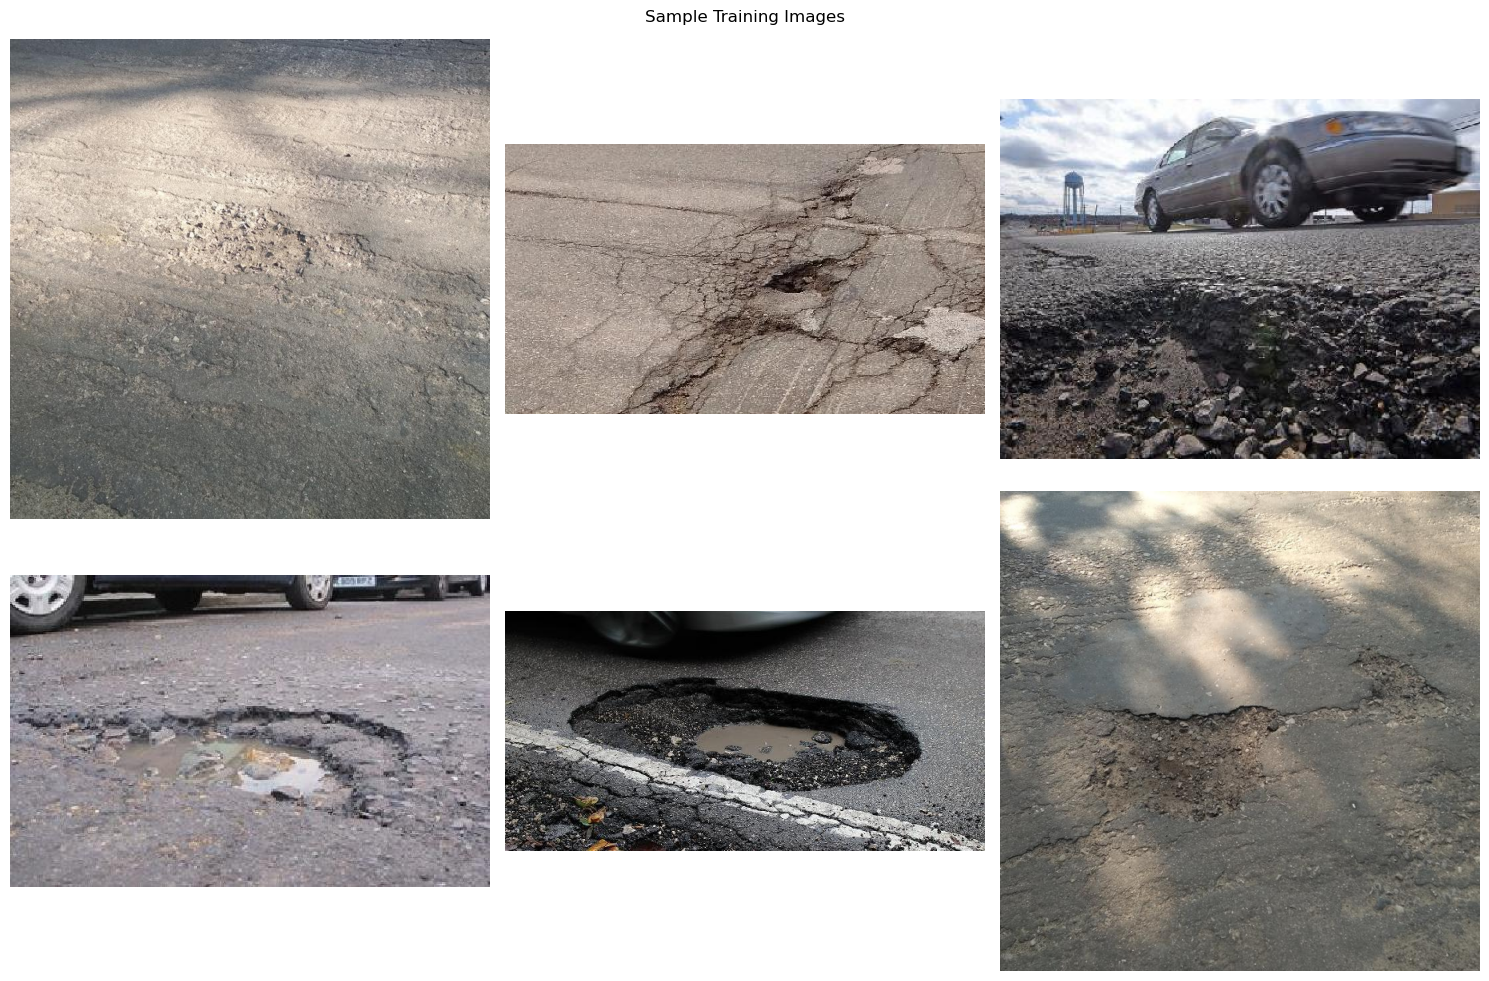

In [10]:
samples = random.sample(train_images, 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, img_file in zip(axes.flatten(), samples):
    img = mpimg.imread(f'../data/train/images/{img_file}')
    ax.imshow(img)
    ax.axis('off')

plt.suptitle('Sample Training Images')
plt.tight_layout()
plt.show()

In [11]:
import cv2

img = cv2.imread(f'../data/train/images/{train_images[0]}')
print(img.shape)

(720, 720, 3)


In [12]:
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [14]:
h, w = img.shape[:2]
print(h, w)

720 720


In [16]:
label_file = train_images[0].replace('.jpg', '.txt')
print(f'Label file: {label_file}')

Label file: img-100_jpg.rf.233751cac3399aa80b5e58a2afbb753a.txt


In [17]:
with open(f'../data/train/labels/{label_file}', 'r') as f:
    lines = f.readlines()
    print(lines)

['0 0.46319444444444446 0.45694444444444443 0.2763888888888889 0.16111111111111112']


In [19]:
_, x_center, y_center, bw, bh = map(float, lines[0].split())

x1 = int((x_center - bw/2) * w)
y1 = int((y_center - bh/2) * h)
x2 = int((x_center + bw/2) * w)
y2 = int((y_center + bh/2) * h)

print(x1, y1, x2, y2)

234 271 433 387


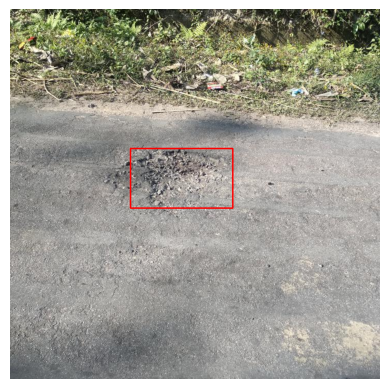

In [20]:
cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

plt.imshow(img)
plt.axis('off')
plt.show()

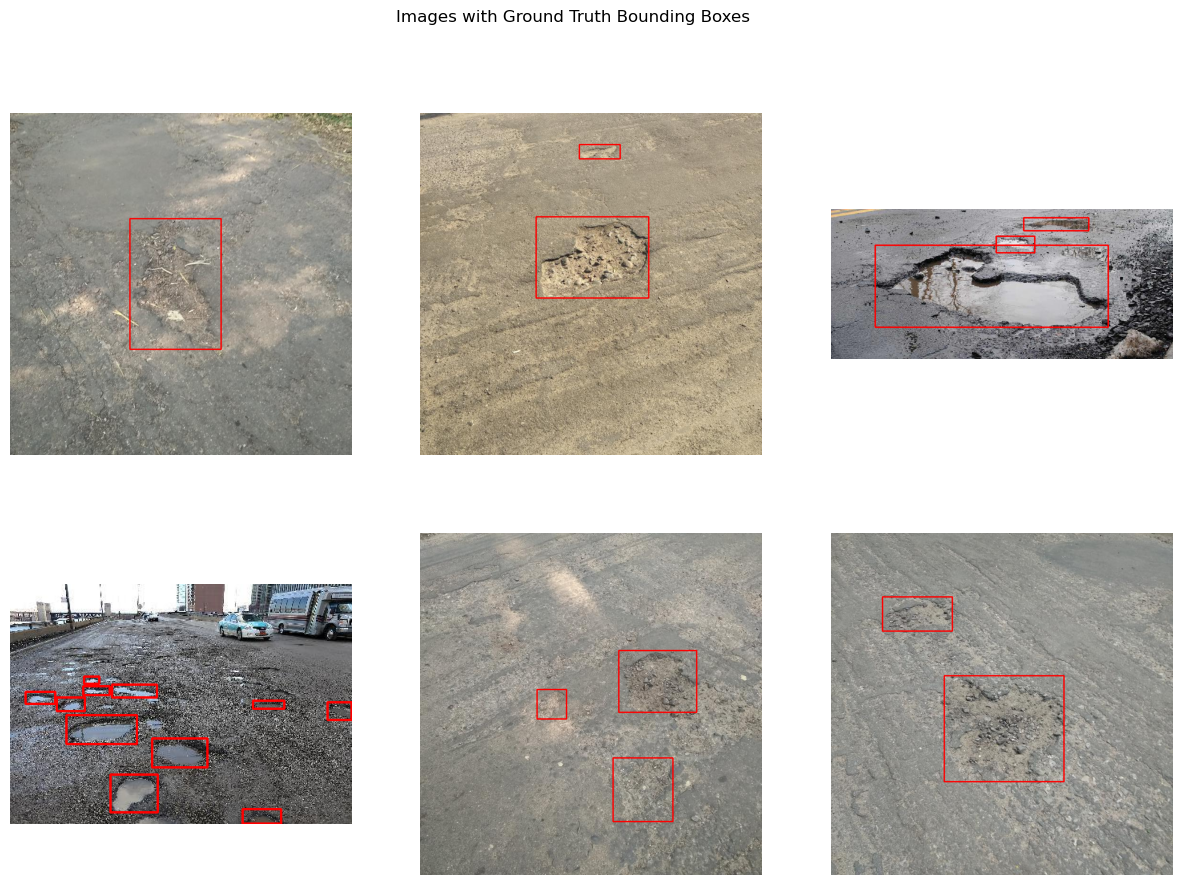

In [21]:
def show_with_boxes(img_file):
    img = cv2.imread(f'../data/train/images/{img_file}')
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    
    label_file = img_file.replace('.jpg', '.txt')
    with open(f'../data/train/labels/{label_file}', 'r') as f:
        for line in f.readlines():
            _, x_center, y_center, bw, bh = map(float, line.split())
            x1 = int((x_center - bw/2) * w)
            y1 = int((y_center - bh/2) * h)
            x2 = int((x_center + bw/2) * w)
            y2 = int((y_center + bh/2) * h)
            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
    return img

samples = random.sample(train_images, 6)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, img_file in zip(axes.flatten(), samples):
    img = show_with_boxes(img_file)
    ax.imshow(img)
    ax.axis('off')

plt.suptitle('Images with Ground Truth Bounding Boxes')
plt.show()

In [23]:
counts = []
widths = []
heights = []

for label_file in os.listdir('../data/train/labels'):
    with open(f'../data/train/labels/{label_file}', 'r') as f:
        lines = f.readlines()
        counts.append(len(lines))
        for line in lines:
            _, _, _, bw, bh = map(float, line.split())
            widths.append(bw)
            heights.append(bh)

print(f"Avg potholes per image: {sum(counts)/len(counts):.2f}")
print(f"Max potholes in one image: {max(counts)}")
print(f"Min potholes in one image: {min(counts)}")

Avg potholes per image: 2.70
Max potholes in one image: 19
Min potholes in one image: 1


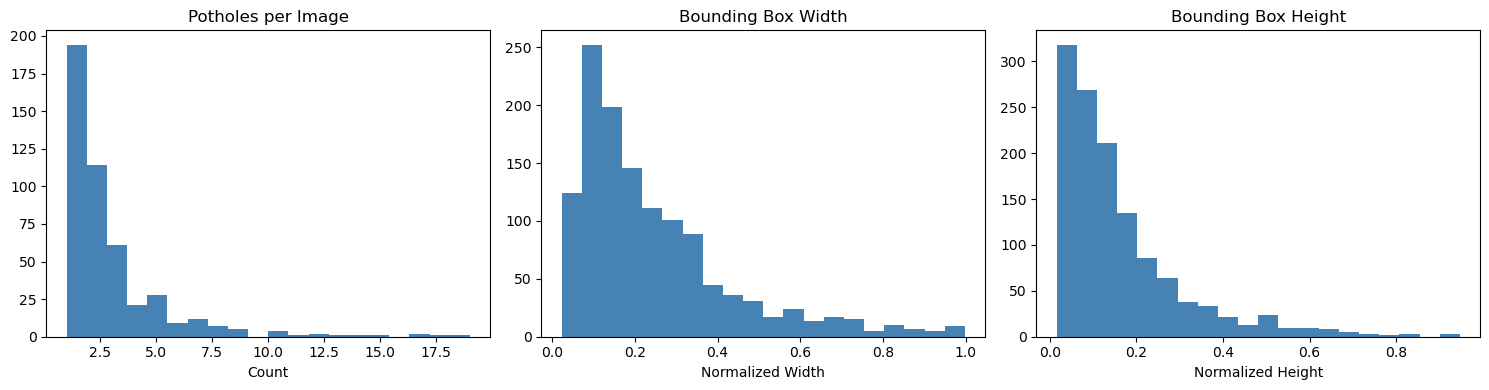

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(counts, bins=20, color='steelblue')
axes[0].set_title('Potholes per Image')
axes[0].set_xlabel('Count')

axes[1].hist(widths, bins=20, color='steelblue')
axes[1].set_title('Bounding Box Width')
axes[1].set_xlabel('Normalized Width')

axes[2].hist(heights, bins=20, color='steelblue')
axes[2].set_title('Bounding Box Height')
axes[2].set_xlabel('Normalized Height')

plt.tight_layout()
plt.show()

## Conclusion

- Dataset contains 665 images split into 465 train, 133 validation, and 67 test images
- Images are 720x720 pixels
- On average there are 2.70 potholes per image, with a maximum of 19
- Bounding box sizes are right skewed, meaning most potholes are relatively small in the image
- Annotations were visually verified and bounding boxes correctly align with potholes
- We will use YOLOv8n for training given the relatively small dataset size